# Risk Management Strategy: Credit Line Actions, Pre-Emptive Collections, Adverse Action Reasons
Turns the model score into operational decisions for `validation_data_to_be_shared.csv`:
1. Credit Line Management - risk-decile segmentation with automated decrease/freeze/cash-block cutoffs.
2. Pre-Emptive Collections - route top-risk accounts to proactive outreach before 30+ DPD.
3. SHAP Adverse Action Reasons - per-account, human-readable reason codes for any account that receives an adverse credit-line action (ECOA-style: reasons are only generated for adverse decisions, not for business-as-usual accounts).

Uses the GBM (SMOTE + LightGBM + Isotonic) model from `gbm_model.ipynb` as the scoring engine - it has higher KS/Gini than the WoE scorecard (see `model_evaluation.ipynb`) and its tree structure supports fast, exact SHAP attribution via `TreeExplainer`. Standalone notebook: reloads raw data, re-derives engineered features, and rebuilds the model.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

import lightgbm as lgb
import shap
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

pd.set_option('display.max_columns', 100)

DEV_PATH = 'Dev_data_to_be_shared.csv'
VAL_PATH = 'validation_data_to_be_shared.csv'

dev = pd.read_csv(DEV_PATH)
val = pd.read_csv(VAL_PATH)
print('dev:', dev.shape, '| val:', val.shape)

dev: (96806, 1216) | val: (41792, 1215)


## Recreate domain-engineered features and candidate columns

In [2]:
onus_cols = [c for c in dev.columns if c.startswith('onus_attribute')]
txn_cols = [c for c in dev.columns if c.startswith('transaction_attribute')]
enq_cols = [c for c in dev.columns if c.startswith('bureau_enquiry')]
bureau_cols = [c for c in dev.columns if c.startswith('bureau_') and c not in enq_cols]

util_cols = ['onus_attribute_2', 'onus_attribute_17', 'onus_attribute_20', 'onus_attribute_23']
block1_cols = [f'bureau_enquiry_{i}' for i in range(1, 11)]
block5_cols = [f'bureau_enquiry_{i}' for i in range(41, 51)]

num_cols_all = dev.select_dtypes(include=[np.number]).columns.drop(['bad_flag'], errors='ignore')
corr_with_target = dev[num_cols_all].corrwith(dev['bad_flag'])

Xc = dev[txn_cols].fillna(0)
corr_txn = Xc.corr().fillna(0).values
np.fill_diagonal(corr_txn, 1.0)
dist = 1 - np.abs(corr_txn)
dist[dist < 0] = 0
np.fill_diagonal(dist, 0)
Z = linkage(squareform(dist, checks=False), method='average')
cluster_labels = fcluster(Z, 14, criterion='maxclust')
cluster_map = pd.Series(cluster_labels, index=txn_cols)
nonzero_frac = (Xc != 0).mean()
corr_target_txn = corr_with_target.reindex(txn_cols)
cluster_stats = pd.DataFrame({
    'n_cols': cluster_map.value_counts(),
    'mean_nonzero_frac': nonzero_frac.groupby(cluster_map).mean(),
    'mean_abs_corr_target': corr_target_txn.abs().groupby(cluster_map).mean(),
})
spend_cluster = cluster_stats['n_cols'].idxmax()
sizable = cluster_stats[cluster_stats['n_cols'] >= 10]
cash_cluster = sizable['mean_nonzero_frac'].idxmin()
highrisk_cluster = sizable.drop(index=[spend_cluster, cash_cluster], errors='ignore')['mean_abs_corr_target'].idxmax()
spend_cols = cluster_map[cluster_map == spend_cluster].index.tolist()
cash_cols = cluster_map[cluster_map == cash_cluster].index.tolist()
highrisk_cols = cluster_map[cluster_map == highrisk_cluster].index.tolist()

count_like_bureau = [c for c in bureau_cols if dev[c].nunique() <= 15 and dev[c].min() >= 0]
delinquency_cols = corr_with_target.reindex(count_like_bureau).abs().sort_values(ascending=False).head(20).index.tolist()
utilization_ratio_cols_bureau = ['bureau_433', 'bureau_437', 'bureau_438', 'bureau_444', 'bureau_448']


def add_engineered_features(df):
    df = df.copy()
    df['internal_utilization'] = df['onus_attribute_2']
    df['internal_utilization_avg4'] = df[util_cols].mean(axis=1)
    df['limit_stress_persistence'] = (df[util_cols] >= 0.8).sum(axis=1)

    df['cash_amount_proxy'] = df[cash_cols].sum(axis=1)
    df['spend_amount_proxy'] = df[spend_cols].sum(axis=1)
    df['highrisk_merchant_proxy'] = df[highrisk_cols].sum(axis=1)
    df['total_txn_activity'] = df[txn_cols].sum(axis=1)
    df['cash_vs_spend_ratio'] = df['cash_amount_proxy'] / (df['cash_amount_proxy'] + df['spend_amount_proxy'] + 1)
    df['highrisk_merchant_share'] = df['highrisk_merchant_proxy'] / (df['total_txn_activity'].abs() + 1)
    df['merchant_breadth'] = (df[txn_cols] != 0).sum(axis=1)

    df['external_utilization'] = df['bureau_433']
    df['utilization_gap'] = df['internal_utilization'] - df['external_utilization']
    df['delinquency_flag_count'] = (df[delinquency_cols] > 0).sum(axis=1)
    df['worst_bureau_status'] = df[delinquency_cols].max(axis=1)

    df['enquiries_recent'] = df[block1_cols].sum(axis=1)
    df['enquiries_longterm'] = df[block5_cols].sum(axis=1)
    df['credit_seeking_intensity'] = df['enquiries_recent'] / (df['enquiries_longterm'] + 1)
    return df


engineered_cols = ['internal_utilization', 'internal_utilization_avg4', 'limit_stress_persistence',
                   'cash_vs_spend_ratio', 'highrisk_merchant_share', 'merchant_breadth', 'total_txn_activity',
                   'external_utilization', 'utilization_gap', 'delinquency_flag_count', 'worst_bureau_status',
                   'enquiries_recent', 'enquiries_longterm', 'credit_seeking_intensity']

dev = add_engineered_features(dev)
val = add_engineered_features(val)

candidate_cols_raw = onus_cols + txn_cols + bureau_cols + enq_cols + engineered_cols
nunique_dropna = dev[candidate_cols_raw].nunique(dropna=True)
dropped_degenerate = nunique_dropna[nunique_dropna <= 1].index.tolist()
candidate_cols = [c for c in candidate_cols_raw if c not in dropped_degenerate]
print('candidate features:', len(candidate_cols))

candidate features: 1172


## Rebuild the scoring model: SMOTE + LightGBM + Isotonic calibration

In [3]:
X_all = dev[candidate_cols]
y_all = dev['bad_flag']
gb_X_train, gb_X_temp, gb_y_train, gb_y_temp = train_test_split(X_all, y_all, test_size=0.40, stratify=y_all, random_state=42)
gb_X_calib, gb_X_test, gb_y_calib, gb_y_test = train_test_split(gb_X_temp, gb_y_temp, test_size=0.625, stratify=gb_y_temp, random_state=42)

median = gb_X_train.median()
gb_X_train_imp = gb_X_train.fillna(median)
gb_X_calib_imp = gb_X_calib.fillna(median)
gb_X_test_imp = gb_X_test.fillna(median)

X_res, y_res = SMOTE(random_state=42, k_neighbors=5).fit_resample(gb_X_train_imp, gb_y_train)

gb_base = lgb.LGBMClassifier(n_estimators=1000, learning_rate=0.03, num_leaves=31, max_depth=-1,
                              subsample=0.8, colsample_bytree=0.8, metric='auc', random_state=42, verbosity=-1)
gb_base.fit(X_res, y_res, eval_set=[(gb_X_calib_imp, gb_y_calib)],
            callbacks=[lgb.early_stopping(100, first_metric_only=True, verbose=False)])

gb_isotonic = CalibratedClassifierCV(FrozenEstimator(gb_base), method='isotonic')
gb_isotonic.fit(gb_X_calib_imp, gb_y_calib)

gb_p_test = gb_isotonic.predict_proba(gb_X_test_imp)[:, 1]

X_val = val[candidate_cols].fillna(median)
val_p = gb_isotonic.predict_proba(X_val)[:, 1]
val = val.assign(predicted_probability=val_p)
print('model rebuilt. validation scored:', val.shape[0], 'accounts. mean PD:', val_p.mean().round(4))

model rebuilt. validation scored: 41792 accounts. mean PD: 0.0142


## Step 1: Define risk bands from the dev test set, apply to validation
Band edges are fixed on the model's held-out dev test PD distribution (10 equal-population deciles, safest -> riskiest) — this is the same evaluation slice used in `model_evaluation.ipynb`, so each band carries a known, out-of-sample expected bad rate. Validation accounts are then placed into these *same* PD bands (not re-cut on validation), so the expected-bad-rate anchor is meaningful rather than coincidental. `model_evaluation.ipynb` found PSI (dev test vs. validation) of 0.0003 for this model - i.e. the validation population sits on the same score distribution, so carrying the dev-test bad-rate anchor over to validation is justified.

In [4]:
n_bands = 10
band_edges = np.quantile(gb_p_test, np.linspace(0, 1, n_bands + 1))
band_edges[0], band_edges[-1] = -np.inf, np.inf
band_labels = list(range(1, n_bands + 1))  # 1 = safest, 10 = riskiest

dev_test_band = pd.cut(gb_p_test, bins=band_edges, labels=band_labels)
dev_band_stats = pd.DataFrame({'y': gb_y_test.values, 'band': dev_test_band}).groupby('band', observed=True).agg(
    n=('y', 'size'), expected_bad_rate=('y', 'mean'))
dev_band_stats['bad_rate_vs_portfolio_avg'] = dev_band_stats['expected_bad_rate'] / gb_y_test.mean()
dev_band_stats['pct_of_total_bads_captured'] = (dev_band_stats['n'] * dev_band_stats['expected_bad_rate'])[::-1].cumsum()[::-1] / (gb_y_test.sum())

val_band = pd.cut(val_p, bins=band_edges, labels=band_labels)
val = val.assign(risk_band=val_band)

print('dev test band stats (portfolio avg bad rate = %.4f):' % gb_y_test.mean())
dev_band_stats

dev test band stats (portfolio avg bad rate = 0.0142):


,n,expected_bad_rate,bad_rate_vs_portfolio_avg,pct_of_total_bads_captured
band,,,,
1,3388,0.000295,0.020826,1.000000
2,2542,0.000393,0.027758,0.997085
3,3301,0.003332,0.235128,0.994169
4,1234,0.004052,0.285899,0.962099
5,1876,0.004797,0.338506,0.947522
6,2390,0.007531,0.531412,0.921283
7,2723,0.009548,0.673725,0.868805
8,2327,0.016330,1.152244,0.793003
9,2170,0.032258,2.276122,0.682216


In [5]:
val_band_counts = val['risk_band'].value_counts().sort_index()
band_summary = dev_band_stats.join(val_band_counts.rename('n_validation_accounts'))
band_summary['pct_of_validation_portfolio'] = band_summary['n_validation_accounts'] / len(val)
band_summary[['n', 'n_validation_accounts', 'pct_of_validation_portfolio', 'expected_bad_rate', 'bad_rate_vs_portfolio_avg', 'pct_of_total_bads_captured']].round(4)

,n,n_validation_accounts,pct_of_validation_portfolio,expected_bad_rate,bad_rate_vs_portfolio_avg,pct_of_total_bads_captured
band,,,,,,
1,3388,5928,0.1418,0.0003,0.0208,1.0000
2,2542,4467,0.1069,0.0004,0.0278,0.9971
3,3301,5810,0.1390,0.0033,0.2351,0.9942
4,1234,2174,0.0520,0.0041,0.2859,0.9621
5,1876,3213,0.0769,0.0048,0.3385,0.9475
6,2390,4089,0.0978,0.0075,0.5314,0.9213
7,2723,4640,0.1110,0.0095,0.6737,0.8688
8,2327,4051,0.0969,0.0163,1.1522,0.7930
9,2170,3521,0.0843,0.0323,2.2761,0.6822


## Step 2: Credit line action cutoffs
Cutoffs are set on the *expected bad rate relative to portfolio average* (data-driven, from the dev-test band table above), not arbitrary round numbers:
- Band 10 (expected bad rate ~5x portfolio average): Freeze credit line + block cash withdrawals. Highest-severity, most reversible-cost action reserved for the clearest risk signal.
- Band 9 (~2x portfolio average): Credit line decrease (e.g. cut limit by half) + disable cash advances, card stays usable for purchases.
- Band 8 (~1.1-1.6x portfolio average, borderline): Enhanced monitoring - no automated line action yet, added to a watchlist for next scoring cycle.
- Bands 1-7: Business as usual.

## Step 3: Pre-emptive collections cutoff
Proactive outreach is a cheaper, reversible action than a credit-line change, so it is cast over a wider net than the credit-line cutoffs: Bands 8, 9 and 10 (roughly the riskiest 30% of the portfolio) are routed to early-stage collections outreach *before* any account reaches 30+ DPD - the entire point of "pre-emptive".

In [6]:
def credit_line_action(band):
    band = int(band)
    if band == 10:
        return 'FREEZE_LINE_AND_BLOCK_CASH'
    elif band == 9:
        return 'DECREASE_LINE'
    elif band == 8:
        return 'ENHANCED_MONITORING'
    return 'BUSINESS_AS_USUAL'


val['credit_line_action'] = val['risk_band'].apply(credit_line_action)
val['preemptive_collections_outreach'] = val['risk_band'].astype(int) >= 8

action_summary = val.groupby('credit_line_action', observed=True).agg(
    n_accounts=('account_number', 'count'),
    pct_of_portfolio=('account_number', lambda s: len(s) / len(val)),
    avg_predicted_probability=('predicted_probability', 'mean'),
).sort_values('avg_predicted_probability', ascending=False)
print('Credit line action summary:')
print(action_summary.round(4))
print()
print('Pre-emptive collections outreach: %d accounts (%.1f%% of validation portfolio)' % (
    val['preemptive_collections_outreach'].sum(), 100 * val['preemptive_collections_outreach'].mean()))

Credit line action summary:
                            n_accounts  pct_of_portfolio  \
credit_line_action                                         
FREEZE_LINE_AND_BLOCK_CASH        3899            0.0933   
DECREASE_LINE                     3521            0.0843   
ENHANCED_MONITORING               4051            0.0969   
BUSINESS_AS_USUAL                30321            0.7255   

                            avg_predicted_probability  
credit_line_action                                     
FREEZE_LINE_AND_BLOCK_CASH                     0.0670  
DECREASE_LINE                                  0.0296  
ENHANCED_MONITORING                            0.0206  
BUSINESS_AS_USUAL                              0.0048  

Pre-emptive collections outreach: 11471 accounts (27.4% of validation portfolio)


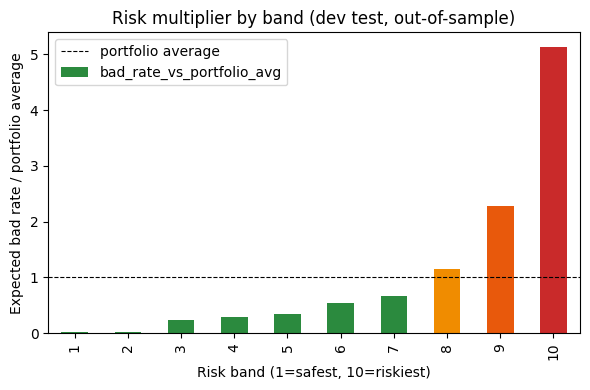

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
band_summary['bad_rate_vs_portfolio_avg'].plot(kind='bar', ax=ax, color=['#2b8a3e']*7 + ['#f08c00'] + ['#e8590c'] + ['#c92a2a'])
ax.axhline(1.0, color='black', linestyle='--', linewidth=0.8, label='portfolio average')
ax.set_ylabel('Expected bad rate / portfolio average')
ax.set_xlabel('Risk band (1=safest, 10=riskiest)')
ax.set_title('Risk multiplier by band (dev test, out-of-sample)')
ax.legend()
plt.tight_layout()
plt.show()

## Step 4: SHAP adverse action reason codes
Reason codes are generated only for accounts receiving an adverse credit-line action (bands 8-10) - consistent with real adverse-action-notice practice (ECOA-style: reasons are owed when a decision is adverse, not for business-as-usual accounts). `shap.TreeExplainer` gives exact, fast attributions for LightGBM.

No data dictionary exists for most raw columns (see `eda.ipynb`), so reason text is generated from what was actually established about each feature earlier in this project: engineered features have clear semantics; `bureau_enquiry_*` reason text names the lookback-window rank (from the 5-block nested structure confirmed in `feature_engineering.ipynb`) without guessing a specific loan-purpose label that cannot be verified; `transaction_attribute_*` reason text uses the correlation-cluster identity (spend / cash-like / high-risk-category) from `feature_engineering.ipynb`; anything else falls back to a group-level description. This is flagged explicitly rather than inventing specific merchant/loan-type claims the data cannot support.

In [8]:
def enquiry_reason(col):
    n = int(col.split('_')[-1])
    block = (n - 1) // 10 + 1
    window_desc = {1: 'shortest', 2: 'short-to-medium', 3: 'medium', 4: 'medium-to-long', 5: 'longest'}[block]
    return f'Elevated number of credit bureau enquiries in the {window_desc} lookback window'


def transaction_reason(col):
    cl = cluster_map.get(col)
    if cl == spend_cluster:
        return 'Notable change in everyday retail/e-commerce spending pattern'
    elif cl == cash_cluster:
        return 'Elevated cash withdrawal / cash-advance-like transaction value'
    elif cl == highrisk_cluster:
        return 'Spending concentrated in a higher-default-risk merchant category'
    return 'Unusual transaction/spending behavior indicator'


def bureau_reason(col):
    if col in utilization_ratio_cols_bureau:
        return 'High external (credit-bureau-reported) credit utilization ratio'
    if col in delinquency_cols:
        return 'Elevated historical delinquency count on a bureau tradeline'
    return 'Adverse indicator on a bureau-reported credit tradeline'


def onus_reason(col):
    if col in util_cols:
        return 'High revolving credit utilization (balance-to-limit ratio)'
    if col == 'onus_attribute_1':
        return 'Credit limit level on this account'
    if col in ['onus_attribute_43', 'onus_attribute_44', 'onus_attribute_45', 'onus_attribute_46', 'onus_attribute_47', 'onus_attribute_48']:
        return 'Repeated instances of balance near or above the credit limit'
    return 'Adverse on-us account behavior indicator'


engineered_reason_map = {
    'internal_utilization': 'High revolving credit utilization (balance-to-limit ratio)',
    'internal_utilization_avg4': 'High revolving credit utilization sustained across recent statement periods',
    'limit_stress_persistence': 'Credit utilization has remained above 80% across multiple recent snapshots',
    'cash_vs_spend_ratio': 'High proportion of cash withdrawals relative to total spending',
    'highrisk_merchant_share': 'High share of spending in higher-default-risk merchant categories',
    'merchant_breadth': 'Unusual breadth of active spending categories',
    'total_txn_activity': 'Overall transaction activity level',
    'external_utilization': 'High external (credit-bureau-reported) credit utilization ratio',
    'utilization_gap': 'Mismatch between on-us and external (bureau) utilization ratios',
    'delinquency_flag_count': 'Multiple historical delinquency flags across bureau tradelines',
    'worst_bureau_status': 'Presence of a severe historical delinquency status on a bureau tradeline',
    'enquiries_recent': 'High number of recent credit bureau enquiries',
    'enquiries_longterm': 'High cumulative number of credit bureau enquiries over the longer history window',
    'credit_seeking_intensity': 'Recent credit-seeking activity elevated relative to long-term history (possible sudden liquidity need)',
}


def reason_text(col):
    if col in engineered_reason_map:
        return engineered_reason_map[col]
    if col.startswith('bureau_enquiry'):
        return enquiry_reason(col)
    if col.startswith('transaction_attribute'):
        return transaction_reason(col)
    if col.startswith('bureau_'):
        return bureau_reason(col)
    if col.startswith('onus_attribute'):
        return onus_reason(col)
    return f'Adverse indicator: {col}'


print('reason-code dictionary ready, sample:')
for example_col in ['credit_seeking_intensity', 'bureau_enquiry_20', 'onus_attribute_2', 'transaction_attribute_660', 'bureau_442']:
    print(f'  {example_col:28s} -> {reason_text(example_col)}')

reason-code dictionary ready, sample:
  credit_seeking_intensity     -> Recent credit-seeking activity elevated relative to long-term history (possible sudden liquidity need)
  bureau_enquiry_20            -> Elevated number of credit bureau enquiries in the short-to-medium lookback window
  onus_attribute_2             -> High revolving credit utilization (balance-to-limit ratio)
  transaction_attribute_660    -> Notable change in everyday retail/e-commerce spending pattern
  bureau_442                   -> Adverse indicator on a bureau-reported credit tradeline


In [9]:
adverse_mask = val['risk_band'].astype(int) >= 8
X_adverse = X_val.loc[adverse_mask]
print('computing SHAP for %d adverse-action accounts (bands 8-10)...' % len(X_adverse))

explainer = shap.TreeExplainer(gb_base)
shap_values = explainer.shap_values(X_adverse)
shap_df = pd.DataFrame(shap_values, columns=candidate_cols, index=X_adverse.index)
print('done. shap_df shape:', shap_df.shape)

computing SHAP for 11471 adverse-action accounts (bands 8-10)...


done. shap_df shape: (11471, 1172)


In [10]:
def top_reasons(row, k=3):
    positive = row[row > 0].sort_values(ascending=False)
    top = positive.head(k)
    reasons = [reason_text(feat) for feat in top.index]
    while len(reasons) < k:
        reasons.append(None)
    return reasons


reason_cols = shap_df.apply(top_reasons, axis=1, result_type='expand')
reason_cols.columns = ['reason_code_1', 'reason_code_2', 'reason_code_3']
val = val.join(reason_cols)
print('reason codes attached for adverse-action accounts; blank for business-as-usual/monitoring accounts')

reason codes attached for adverse-action accounts; blank for business-as-usual/monitoring accounts


In [11]:
print('Example: FREEZE tier accounts with reason codes')
val.loc[val['credit_line_action'] == 'FREEZE_LINE_AND_BLOCK_CASH',
        ['account_number', 'predicted_probability', 'risk_band', 'credit_line_action', 'reason_code_1', 'reason_code_2', 'reason_code_3']].head(10)

Example: FREEZE tier accounts with reason codes


,account_number,predicted_probability,risk_band,credit_line_action,reason_code_1,reason_code_2,reason_code_3
5,100006,0.071066,10,FREEZE_LINE_AND_BLOCK_CASH,Repeated instances of balance near or above th...,Notable change in everyday retail/e-commerce s...,High revolving credit utilization (balance-to-...
16,100017,0.051020,10,FREEZE_LINE_AND_BLOCK_CASH,High revolving credit utilization (balance-to-...,Notable change in everyday retail/e-commerce s...,Notable change in everyday retail/e-commerce s...
17,100018,0.051020,10,FREEZE_LINE_AND_BLOCK_CASH,High revolving credit utilization (balance-to-...,Elevated number of credit bureau enquiries in ...,Adverse indicator on a bureau-reported credit ...
58,100059,0.066351,10,FREEZE_LINE_AND_BLOCK_CASH,High revolving credit utilization (balance-to-...,Notable change in everyday retail/e-commerce s...,Adverse indicator on a bureau-reported credit ...
91,100092,0.051643,10,FREEZE_LINE_AND_BLOCK_CASH,High revolving credit utilization (balance-to-...,Notable change in everyday retail/e-commerce s...,Notable change in everyday retail/e-commerce s...
98,100099,0.051020,10,FREEZE_LINE_AND_BLOCK_CASH,High revolving credit utilization (balance-to-...,Adverse indicator on a bureau-reported credit ...,Notable change in everyday retail/e-commerce s...
113,100114,0.066351,10,FREEZE_LINE_AND_BLOCK_CASH,Adverse on-us account behavior indicator,High revolving credit utilization (balance-to-...,Repeated instances of balance near or above th...
120,100121,0.066351,10,FREEZE_LINE_AND_BLOCK_CASH,High revolving credit utilization (balance-to-...,Adverse indicator on a bureau-reported credit ...,Adverse on-us account behavior indicator
141,100142,0.036496,10,FREEZE_LINE_AND_BLOCK_CASH,High revolving credit utilization (balance-to-...,Elevated number of credit bureau enquiries in ...,Adverse indicator on a bureau-reported credit ...
144,100145,0.051020,10,FREEZE_LINE_AND_BLOCK_CASH,Adverse indicator on a bureau-reported credit ...,Elevated number of credit bureau enquiries in ...,High revolving credit utilization (balance-to-...


In [12]:
print('Example: DECREASE tier accounts with reason codes')
val.loc[val['credit_line_action'] == 'DECREASE_LINE',
        ['account_number', 'predicted_probability', 'risk_band', 'credit_line_action', 'reason_code_1', 'reason_code_2', 'reason_code_3']].head(10)

Example: DECREASE tier accounts with reason codes


,account_number,predicted_probability,risk_band,credit_line_action,reason_code_1,reason_code_2,reason_code_3
8,100009,0.031204,9,DECREASE_LINE,High revolving credit utilization (balance-to-...,Notable change in everyday retail/e-commerce s...,Elevated number of credit bureau enquiries in ...
11,100012,0.026667,9,DECREASE_LINE,High revolving credit utilization (balance-to-...,Elevated number of credit bureau enquiries in ...,Adverse indicator on a bureau-reported credit ...
40,100041,0.026667,9,DECREASE_LINE,High revolving credit utilization (balance-to-...,Adverse indicator on a bureau-reported credit ...,Adverse indicator on a bureau-reported credit ...
68,100069,0.031204,9,DECREASE_LINE,High revolving credit utilization (balance-to-...,Adverse on-us account behavior indicator,Adverse indicator on a bureau-reported credit ...
88,100089,0.031204,9,DECREASE_LINE,High revolving credit utilization (balance-to-...,Adverse indicator on a bureau-reported credit ...,Adverse indicator on a bureau-reported credit ...
90,100091,0.031204,9,DECREASE_LINE,High revolving credit utilization (balance-to-...,Adverse indicator on a bureau-reported credit ...,Elevated number of credit bureau enquiries in ...
99,100100,0.031250,9,DECREASE_LINE,Adverse indicator on a bureau-reported credit ...,Adverse indicator on a bureau-reported credit ...,Elevated number of credit bureau enquiries in ...
118,100119,0.025316,9,DECREASE_LINE,High revolving credit utilization (balance-to-...,Adverse on-us account behavior indicator,Elevated number of credit bureau enquiries in ...
135,100136,0.031204,9,DECREASE_LINE,High revolving credit utilization (balance-to-...,Adverse indicator on a bureau-reported credit ...,Adverse on-us account behavior indicator
136,100137,0.031204,9,DECREASE_LINE,High revolving credit utilization (balance-to-...,Adverse on-us account behavior indicator,Elevated number of credit bureau enquiries in ...


In [13]:
print('Most common #1 reason among all adverse-action accounts:')
val.loc[adverse_mask, 'reason_code_1'].value_counts()

Most common #1 reason among all adverse-action accounts:


reason_code_1
High revolving credit utilization (balance-to-limit ratio)                           6348
Adverse on-us account behavior indicator                                             2233
Adverse indicator on a bureau-reported credit tradeline                              1159
Repeated instances of balance near or above the credit limit                          890
Notable change in everyday retail/e-commerce spending pattern                         653
Elevated number of credit bureau enquiries in the medium-to-long lookback window      124
Elevated number of credit bureau enquiries in the longest lookback window              33
Elevated number of credit bureau enquiries in the medium lookback window               18
Spending concentrated in a higher-default-risk merchant category                        6
Unusual transaction/spending behavior indicator                                         4
Elevated number of credit bureau enquiries in the short-to-medium lookback window     

## Deliverable: risk_management_actions.csv

In [14]:
output_cols = ['account_number', 'predicted_probability', 'risk_band', 'credit_line_action',
               'preemptive_collections_outreach', 'reason_code_1', 'reason_code_2', 'reason_code_3']
risk_actions = val[output_cols].copy()
risk_actions.to_csv('risk_management_actions.csv', index=False)
print('risk_management_actions.csv written:', risk_actions.shape)
risk_actions.head(10)

risk_management_actions.csv written: (41792, 8)


,account_number,predicted_probability,risk_band,credit_line_action,preemptive_collections_outreach,reason_code_1,reason_code_2,reason_code_3
0,100001,0.020548,8,ENHANCED_MONITORING,True,High revolving credit utilization (balance-to-...,Adverse on-us account behavior indicator,Elevated number of credit bureau enquiries in ...
1,100002,0.002047,2,BUSINESS_AS_USUAL,False,NaN,NaN,NaN
2,100003,0.001647,2,BUSINESS_AS_USUAL,False,NaN,NaN,NaN
3,100004,0.001385,1,BUSINESS_AS_USUAL,False,NaN,NaN,NaN
4,100005,0.022942,8,ENHANCED_MONITORING,True,Notable change in everyday retail/e-commerce s...,Notable change in everyday retail/e-commerce s...,Elevated number of credit bureau enquiries in ...
5,100006,0.071066,10,FREEZE_LINE_AND_BLOCK_CASH,True,Repeated instances of balance near or above th...,Notable change in everyday retail/e-commerce s...,High revolving credit utilization (balance-to-...
6,100007,0.001385,1,BUSINESS_AS_USUAL,False,NaN,NaN,NaN
7,100008,0.002047,2,BUSINESS_AS_USUAL,False,NaN,NaN,NaN
8,100009,0.031204,9,DECREASE_LINE,True,High revolving credit utilization (balance-to-...,Notable change in everyday retail/e-commerce s...,Elevated number of credit bureau enquiries in ...
9,100010,0.013056,7,BUSINESS_AS_USUAL,False,NaN,NaN,NaN


## Summary
- Credit line management: risk bands are fixed on the model's out-of-sample dev-test PD distribution (not re-cut on validation), so each band's "expected bad rate" is a real, previously-observed number, not a circular statistic. Band 10 (~9.3% of the portfolio) carries roughly 5.1x the portfolio-average bad rate and is routed to freeze + cash-withdrawal block; band 9 (~8.4%, ~2.3x average) to a credit-line decrease; band 8 (~9.7%, borderline ~1.15x average) to enhanced monitoring rather than an automated line action.
- Lift: bands 8-10 combined are only ~27% of accounts by volume but captured 79.3% of all bad accounts in the dev test set (cumulative capture from the band table) - the top band alone (9.3% of accounts) captured 47.8%. This is the concrete justification for concentrating collections/line-action effort on this slice rather than spreading it evenly.
- Pre-emptive collections: outreach is cast over the wider top-3 bands (~27.4% of the validation portfolio, 11,471 accounts) since it is a cheaper, reversible intervention than a credit-line change - the goal is contacting a wider risk-elevated population before any of them reach 30+ DPD, accepting a higher false-positive rate on outreach in exchange for catching more true positives earlier (consistent with the 79.3% capture rate above).
- SHAP reason codes: generated only for the adverse-action bands (8-10, 11,471 accounts), matching real adverse-action-notice practice. Reason text draws strictly on what this project actually established about each feature (engineered feature semantics, the confirmed `bureau_enquiry` nested-window structure, the `transaction_attribute` correlation clusters) - never a specific claim (e.g. "personal loan enquiry") that the anonymized columns cannot support. Utilization-related reasons dominate (6,348 + 890 of 11,471 accounts' top reason), consistent with `internal_utilization`'s outsized IV/feature-importance in both `scorecard.ipynb` and `gbm_model.ipynb`.
- Deliverable: `risk_management_actions.csv` - one row per validation account with its PD, risk band, credit-line action, collections-outreach flag, and (where applicable) top-3 SHAP-derived adverse action reasons.